<a href="https://colab.research.google.com/github/fabiospiazzi/Proj_Final_Mod1_SCTec/blob/feat%2Ffase_2_data_prep/Projeto_Final_Mod_1_SCTEC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

O Problema: Um parque fabril monitorado por sensores necessita prever quebras mecânicas nos equipamentos para evitar paradas na linha de produção. A variável alvo do projeto é binária: Falha = 1 (quando há uma avaria detectada) e Falha = 0 (funcionamento normal).

# Carregando os Dados

In [1]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')
#

Mounted at /content/drive


In [2]:
# Carregar arquivo CSV
import pandas as pd

# Caminho do meu drive. Para reprodução em outra máquina, baixar o arquivo CSV e alterar o caminho
caminho = '/content/drive/MyDrive/Curso SCTec/IA para análise preditiva 300 h/Projeto Final - Mod_1/manutencao_preditiva.csv'
dados = pd.read_csv(caminho) # Configuraçãoes default do pandas read CSV.
dados.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [3]:
# Separação Target e Preditoras para EDA

y = dados['falha_maquina']    # Target
X = dados.iloc[:, 2:8]        # Preditoras
dados_juntados = pd.concat([X, y], axis=1) # Dados juntados para serem limpos
dados_juntados.head()

,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina
0,M,298.1,308.6,1551.0,42.8,0,0
1,L,298.2,308.7,1408.0,46.3,3,0
2,L,298.1,308.5,1498.0,49.4,5,0
3,L,NaN,NaN,NaN,NaN,7,0
4,L,298.2,308.7,1408.0,40.0,9,0


In [ ]:
# Cabeçalho da Target
y.head()

,falha_maquina
0,0
1,0
2,0
3,0
4,0


In [ ]:
# Cabeçalho das Preditoras
X.head()

,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min
0,M,298.1,308.6,1551.0,42.8,0
1,L,298.2,308.7,1408.0,46.3,3
2,L,298.1,308.5,1498.0,49.4,5
3,L,NaN,NaN,NaN,NaN,7
4,L,298.2,308.7,1408.0,40.0,9


# FASE 1 - Análise Exploratória

## - Apresente as dimensões do dataset (número de linhas e colunas), os tipos de dados das variáveis e o resumo estatístico descritivo das colunas numéricas via método “.describe()”.

In [ ]:
# Todo o Dataset
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  object 
 2   tipo                     10000 non-null  object 
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 12  falha_osf                10000 non-null  int64  
 13  falha_rnf                10000 non-null  int64  
dtypes: float64(4), int64(8)

É possível observar na célula acima que o dataset possui, na sua maioria, 10000 registros com 14 colunas, sendo que há algumas colunas com apenas 9500, ou seja, deverão ser tratado quanto a valores NaN.

In [ ]:
# Todo o Dataset
dados.describe()

,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
# Estrutuda do Datase das Variáveis Preditoras
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tipo                     10000 non-null  object 
 1   temperatura_ar_k         9500 non-null   float64
 2   temperatura_processo_k   9500 non-null   float64
 3   velocidade_rotacao_rpm   9500 non-null   float64
 4   torque_nm                9500 non-null   float64
 5   desgaste_ferramenta_min  10000 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 468.9+ KB


In [ ]:
# Estatística Descritiva das Variáveis Preditoras
X.describe()

,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min
count,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000
mean,300.002158,310.000895,1539.245263,39.974168,107.951000
std,2.001689,1.486432,180.273589,9.995453,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.100000,53.000000
50%,300.100000,310.100000,1504.000000,40.100000,108.000000
75%,301.500000,311.100000,1613.000000,46.700000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


## - Plote, no mínimo, 3 gráficos analíticos bem fundamentados utilizando bibliotecas como Matplotlib ou Seaborn (Ex: histograma de distribuição das variáveis preditoras, gráfico de barras comprovando a taxa de desbalanceamento da variável alvo e um mapa de calor com a correlação de Pearson entre as variáveis).

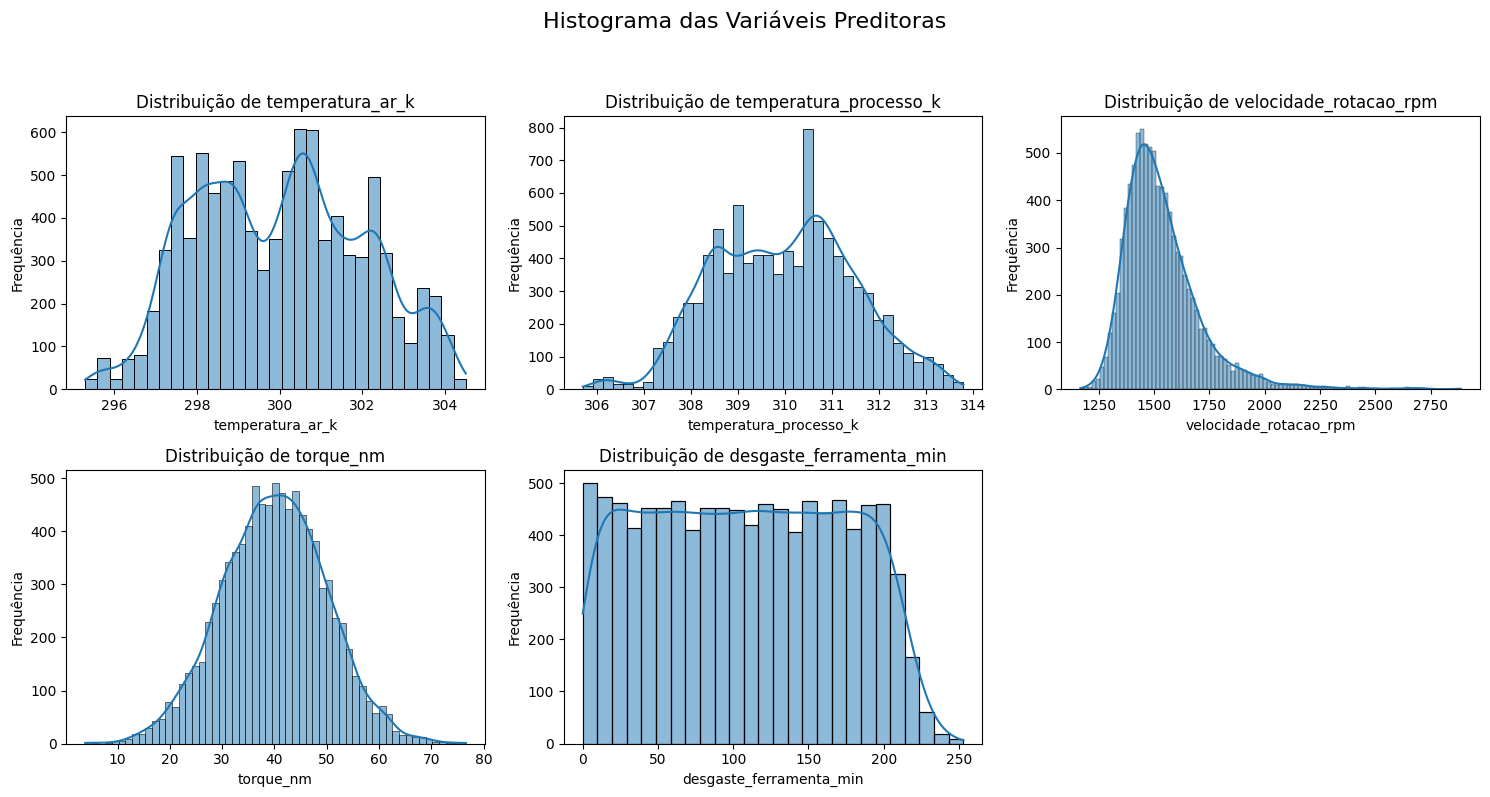

In [ ]:
# Histograma das variáveis preditoras
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando apenas as colunas numéricas de X
numerical_cols = X.select_dtypes(include=['number']).columns

# Determinando o número de linhas e colunas para os subplots
n_cols = 3  # 3 colunas de histogramas
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Calcula o número de linhas necessário

plt.figure(figsize=(n_cols * 5, n_rows * 4))
plt.suptitle('Histograma das Variáveis Preditoras', y=1.02, fontsize=16)

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(X[col].dropna(), kde=True) # dropna() para lidar com NaN e kde para estimativa de densidade
    plt.title(f'Distribuição de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Ajusta o layout para evitar sobreposição
plt.show()

Nos gráficos (de Histograma) acima, podemos observar a distribuição das variáveis preditoras do dataset, ainda sem limpeza e tratamento, ou seja, os dados originais (raw). Visualmente ja é possível identificar alguns possíveis pontos de outliers, como no caso da variável "temperatura_processo_k".

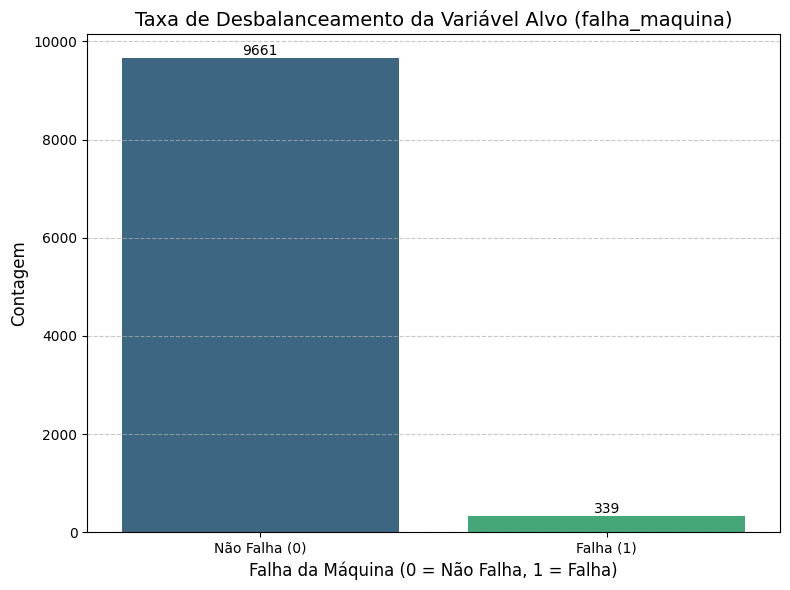

In [ ]:
# Gráfico de barras para verificar a taxa de desbalanceamento entre as classes
# da variável alvo (target) - "falha_maquina".

import matplotlib.pyplot as plt
import seaborn as sns

# Contar as ocorrências de cada classe na variável alvo
imbalance_counts = y.value_counts()

# Criar o gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(x=imbalance_counts.index, y=imbalance_counts.values, hue=imbalance_counts.index, palette='viridis', legend=False)
plt.title('Taxa de Desbalanceamento da Variável Alvo (falha_maquina)', fontsize=14)
plt.xlabel('Falha da Máquina (0 = Não Falha, 1 = Falha)', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Não Falha (0)', 'Falha (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores acima das barras
for index, value in enumerate(imbalance_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()

A taxa de desbalanceamento do dataset é de 99,60% para a classe majoritária (Não Falha) e 0,40% para a classe minoritária (Falha), configurando um cenário de desbalanceamento extremo. No gráfico (de barras) acima é possível notar esse desbalancemento que será devidamente tratado na Fase 4 deste projeto, quando iremos separar entre treinamento e teste; e aplicar uma técnica de reamostragem (SMOTE).

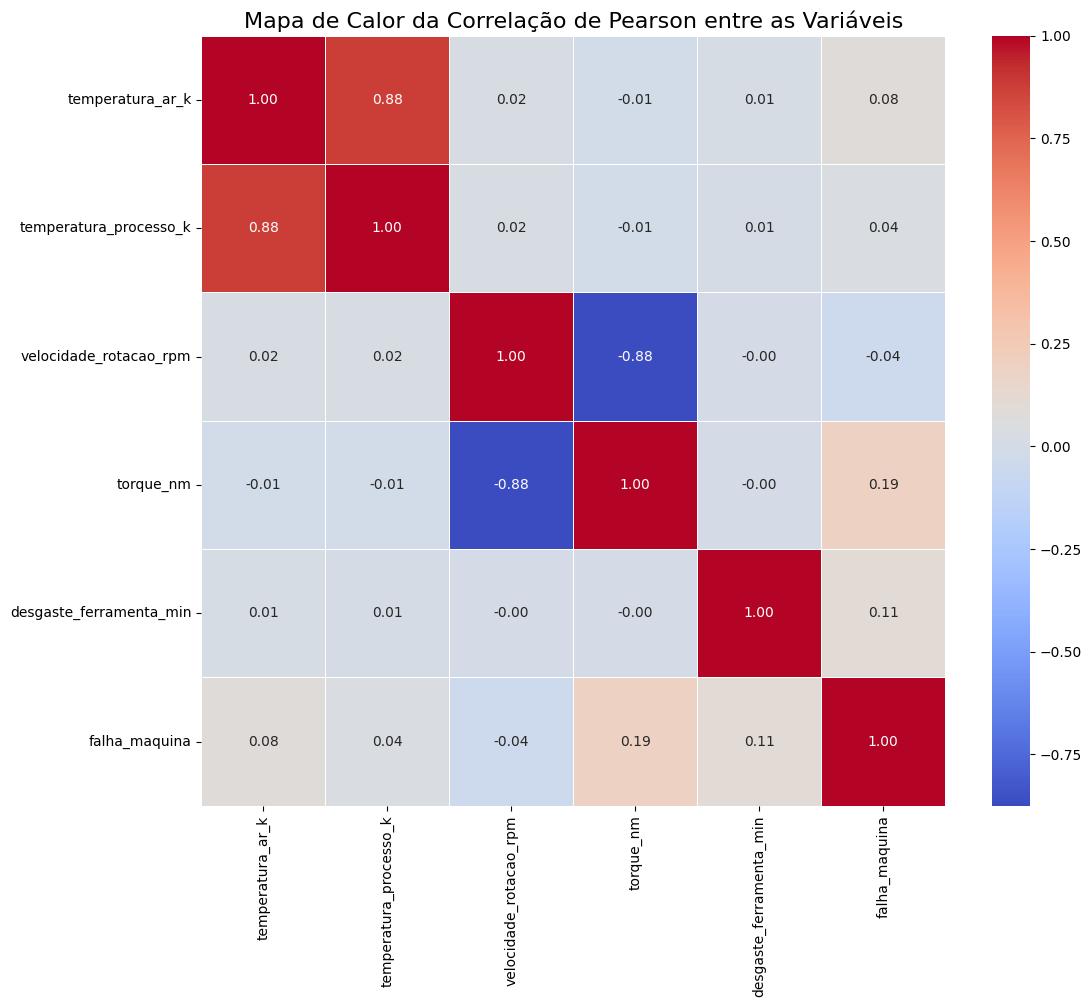

In [ ]:
# Mapa de calor com a correlação de Pearson entre as variáveis
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Juntar as variáveis preditoras (X) e a variável alvo (y)
# Certificar-se de que X contém apenas colunas numéricas para o cálculo da correlação
df_corr = X.select_dtypes(include=['number']).copy()
df_corr['falha_maquina'] = y

# Calcular a matriz de correlação de Pearson
correlation_matrix = df_corr.corr(method='pearson')

# Criar o mapa de calor
plt.figure(figsize=(12, 10)) # Ajuste o tamanho conforme necessário
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Mapa de Calor da Correlação de Pearson entre as Variáveis', fontsize=16)
plt.show()

O mapa de calor da correlação de Pearson acima mostra a força da correlação direta ou indirenta entre todas as variáveis do daset. Neste primeiro momento é possível observar que há uma correlação forte entre duas variáveis preditoras (0.88), entre "temperatura_ar_k" e "temperatura_processo_k", fato que demonstra uma potencial colinearidade entre essas features preditoras. Muito provavelmente uma dessas variaveis será eliminada na fase de treinamento do modelo. Este gráfico também nos mostra uma correlação positiva, relativamente fraca, entre a variável Target "falha_maquina" e "torque_nm".

# FASE 2 - Limpeza e Tratamento de Dados (Data Prep)

## - Identifique e remova as linhas duplicadas.

In [4]:
# Identificação das linha duplicadas

dados_juntados.duplicated().sum()
print(f'Linhas duplicadas a serem removidas: {dados_juntados.duplicated().sum()}')

Linhas duplicadas a serem removidas: 185


In [5]:
# Remoção das linha duplicadas

dados_juntados.drop_duplicates(inplace=True)
print(f'Linhas duplicadas: {dados_juntados.duplicated().sum()}')

Linhas duplicadas: 0


In [6]:
# Verificação da base de dados
dados_juntados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9815 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tipo                     9815 non-null   object 
 1   temperatura_ar_k         9500 non-null   float64
 2   temperatura_processo_k   9500 non-null   float64
 3   velocidade_rotacao_rpm   9500 non-null   float64
 4   torque_nm                9500 non-null   float64
 5   desgaste_ferramenta_min  9815 non-null   int64  
 6   falha_maquina            9815 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 613.4+ KB


## - Identifique dados ausentes e aplique a imputação por Média ou Mediana, justificando textualmente a escolha com base na distribuição dos dados.



## - Geração de gráficos do tipo boxplot para identificar a presença de outliers nas variáveis explicativas.

In [ ]:
dados_juntados

,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina
0,M,298.1,308.6,1551.0,42.8,0,0
1,L,298.2,308.7,1408.0,46.3,3,0
2,L,298.1,308.5,1498.0,49.4,5,0
3,L,NaN,NaN,NaN,NaN,7,0
4,L,298.2,308.7,1408.0,40.0,9,0
...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604.0,29.5,14,0
9996,H,298.9,308.4,1632.0,31.8,17,0
9997,M,299.0,308.6,1645.0,33.4,22,0
9998,H,299.0,308.7,1408.0,48.5,25,0


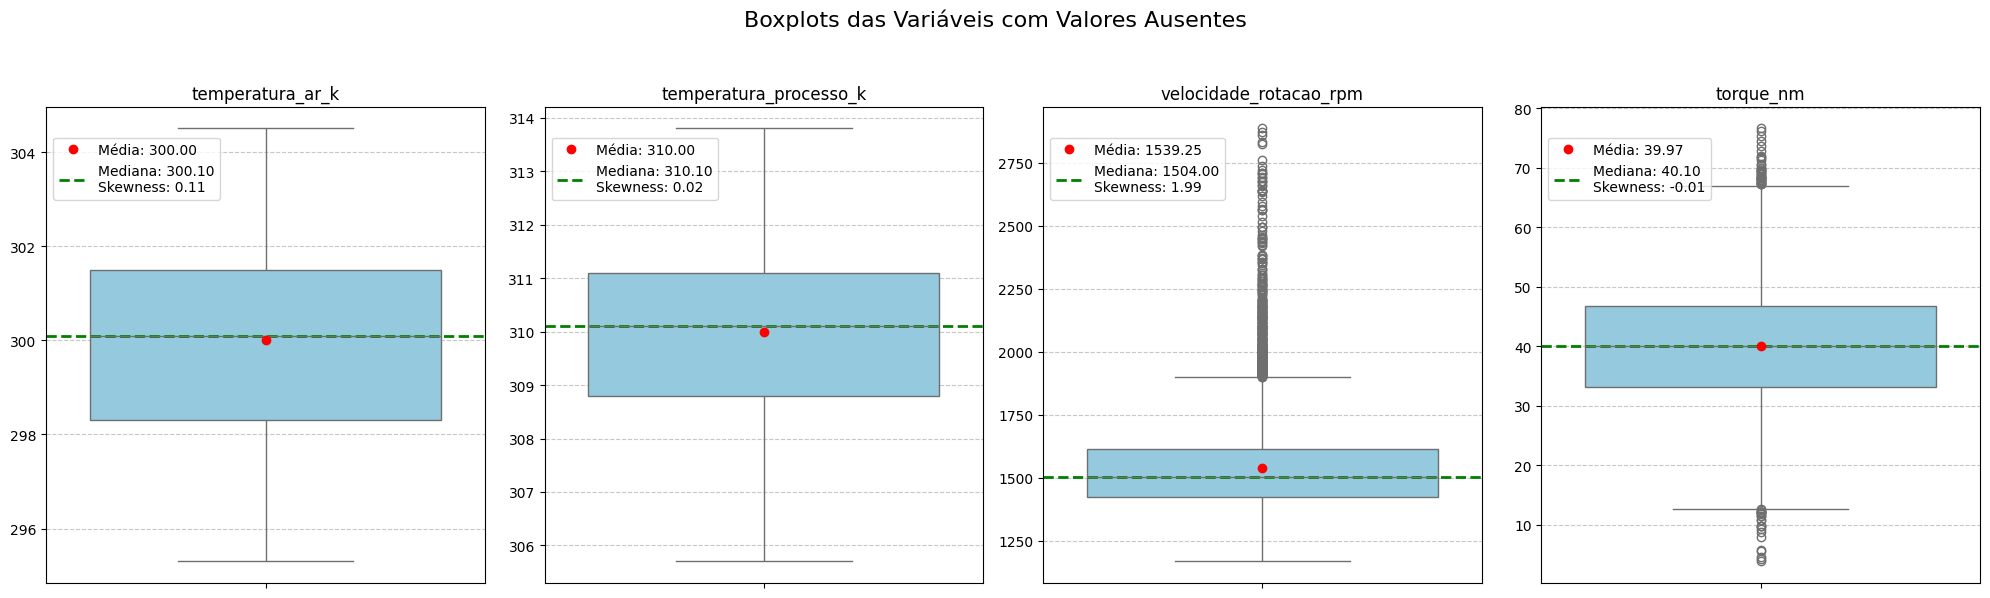


--- Estatísticas e Sugestões de Imputação ---

Variável: temperatura_ar_k
  Média: 300.00
  Mediana: 300.10
  Skewness: 0.11
  Sugestão de Imputação: Média (Skewness está entre -0.5 e 0.5)

Variável: temperatura_processo_k
  Média: 310.00
  Mediana: 310.10
  Skewness: 0.02
  Sugestão de Imputação: Média (Skewness está entre -0.5 e 0.5)

Variável: velocidade_rotacao_rpm
  Média: 1539.25
  Mediana: 1504.00
  Skewness: 1.99
  Sugestão de Imputação: Mediana (Skewness está fora do intervalo [-0.5, 0.5])

Variável: torque_nm
  Média: 39.97
  Mediana: 40.10
  Skewness: -0.01
  Sugestão de Imputação: Média (Skewness está entre -0.5 e 0.5)


In [19]:
# Regra geral para imputação:
# - Distribuição simétrica: média
# - Distribuição assimétrica: mediana

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D

# Geração de Boxplots para as 4 variáveis preditoras com valores NaN

columns_to_analyze = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm']

n_cols = len(columns_to_analyze)
plt.figure(figsize=(n_cols * 5, 6))
plt.suptitle('Boxplots das Variáveis com Valores Ausentes', y=1.02, fontsize=16)

statistics = {}

# Itera sobre cada coluna para gerar um boxplot individual
for i, col in enumerate(columns_to_analyze):
    plt.subplot(1, n_cols, i + 1)
    # Plota o boxplot, mostrando a média com um marcador específico
    sns.boxplot(y=dados_juntados[col], color='skyblue', showmeans=True,
                meanprops={"marker":"o","markerfacecolor":"red", "markeredgecolor":"red", "markersize":"6"})

    # Calcula a média, mediana e assimetria (skewness) da coluna
    mean_val = dados_juntados[col].mean()
    median_val = dados_juntados[col].median()
    skew_val = dados_juntados[col].skew()
    statistics[col] = {'Média': mean_val, 'Mediana': median_val, 'Skewness': skew_val}

    # Cria um objeto 'proxy artist' para incluir o marcador da média na legenda
    mean_marker_handle = Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='red', markersize=6, label=f'Média: {mean_val:.2f}')

    # Plota a linha da mediana e cria seu rótulo para a legenda
    median_line_handle = plt.axhline(median_val, color='green', linestyle='--', linewidth=2,
                                     label=f'Mediana: {median_val:.2f}\nSkewness: {skew_val:.2f}')

    plt.title(col)
    plt.ylabel('')

    # Combina os 'handles' e rótulos para construir a legenda
    handles = [mean_marker_handle, median_line_handle]
    labels = [h.get_label() for h in handles]

    # Ajusta a localização e posição da legenda (canto superior esquerdo, ligeiramente para baixo)
    plt.legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(0, 0.95))

    plt.grid(axis='y', linestyle='--', alpha=0.7)


# Ajusta o layout para evitar sobreposição dos títulos e elementos
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# Seção complementar para imprimir estatísticas e sugestões de imputação

print('\n--- Estatísticas e Sugestões de Imputação ---')
for col, stats in statistics.items():
    print(f'\nVariável: {col}')
    print(f"  Média: {stats['Média']:.2f}")
    print(f"  Mediana: {stats['Mediana']:.2f}")
    print(f"  Skewness: {stats['Skewness']:.2f}")

    # Lógica para sugerir imputação baseada na assimetria (Skewness)
    if -0.5 <= stats['Skewness'] <= 0.5:
        print(f"  Sugestão de Imputação: Média (Skewness está entre -0.5 e 0.5)")
    else:
        print(f"  Sugestão de Imputação: Mediana (Skewness está fora do intervalo [-0.5, 0.5])")

A escolha da imputação da média ou mediana se deu por dois parâmetros principais a saber:
- Análise de distribuição dos dados: visualmente é possível observar se os dados estão uniformemente diestribuitos e se há discrepãncia entre eles. Observando os gráficos da Fase 1 dá a impressão de que a variável "temperatura_processo_k" é a menos simétrica, porém sua média e mediana são praticamente identicas, o que nos leva a segunda parte da análise,
- Coeficiente de assimetria ou Skewness, que segundo a literatura, classifica as distribuiçõesm em assimétricas e simétricas a depender deste coeficiente. Na referência que consultei, é citado um intervalo entre [-1,1], mas no código utilizei [-0.5,0.5] para ser um pouco mais criterioso. Como os dados são praticamente simétricos (Exceto para Velocidade de Rotação), somente para esta é que foi imputada a mediana. Ver referências:

George, D. Mallery, P. SPSS for Windows Step by Step: A Simple Guide and Reference. 14 ed. Taylor & Francis. 2016. Disponível em: https://knowledgezone.home.blog/wp-content/uploads/2019/05/wp-1558033893715.pdf


In [21]:
# Imputação de média e mediana nas variáveis

dados_juntados['temperatura_ar_k'] = dados_juntados['temperatura_ar_k'].fillna(dados_juntados['temperatura_ar_k'].mean())
dados_juntados['temperatura_processo_k'] = dados_juntados['temperatura_processo_k'].fillna(dados_juntados['temperatura_processo_k'].mean())
dados_juntados['velocidade_rotacao_rpm'] = dados_juntados['velocidade_rotacao_rpm'].fillna(dados_juntados['velocidade_rotacao_rpm'].median())
dados_juntados['torque_nm'] = dados_juntados['torque_nm'].fillna(dados_juntados['torque_nm'].mean())

In [22]:
# Verificação se a imputação ocrreu

dados_juntados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9815 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tipo                     9815 non-null   object 
 1   temperatura_ar_k         9815 non-null   float64
 2   temperatura_processo_k   9815 non-null   float64
 3   velocidade_rotacao_rpm   9815 non-null   float64
 4   torque_nm                9815 non-null   float64
 5   desgaste_ferramenta_min  9815 non-null   int64  
 6   falha_maquina            9815 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 613.4+ KB


In [25]:
# Estatística descritiva após a imputação

dados_juntados.describe()

,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina
count,9815.000000,9815.000000,9815.000000,9815.000000,9815.000000,9815.000000
mean,300.002158,310.000895,1538.114111,39.974168,108.119511,0.034437
std,1.969303,1.462383,177.465638,9.833733,63.595598,0.182358
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,298.400000,308.900000,1425.000000,33.400000,53.000000,0.000000
50%,300.002158,310.000895,1504.000000,39.974168,108.000000,0.000000
75%,301.500000,311.000000,1609.000000,46.500000,163.000000,0.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


# FASE 3 - Feature Engineering